# ETL, Plots and Storytelling Project. PART 3

For this projet, we will work with real-world data and engage our audience (business stakeholders and decision-makers) through a range of visualizations and reports.

The project is structured into five sections:

Section 1 – Sales Trend Over Time. \
Section 2 – Grouping and Summarization. \
Section 3 – Payment Analysis. \
Section 4 – Customer Satisfaction Level. \
Section 5 – Marketing Analytics Metrics. 

This is an extensive project, involving a large number of analyses in Python. The visualizations depend on the data, so we will preprocess and adjust the data before creating each chart. For each section, we will address multiple business questions using visualizations and storytelling.

This is a project made of 3 parts, this is the third and last one. 

Loading Libraries

In [1]:
# Imports

import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
from datetime import datetime, timedelta
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go
import plotly.graph_objects as go
from plotly import tools
import plotly.express as px
import colorlover as cl
import warnings
warnings.filterwarnings('ignore')

## Loading and understanding data

In [2]:
# Loading dataset

FILE_ID = "1ikA5f7Y6ccuy1pPlR6kV569p4xtQoo05"

url = f"https://drive.google.com/uc?id={FILE_ID}"

df = pd.read_csv(url)

In [3]:
# Shape

df.shape

(116581, 53)

In [4]:
# Data Sample

df.sample(10)

,order_id,order_id3,customer_id3,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,seller_city,seller_state,product_category_name_english,review_response_time,order_purchase_year,order_purchase_month,order_purchase_dayofweek,order_purchase_hour,order_purchase_day,order_purchase_mon
49121,ON18284,a7b3d17383515918f57cc831f29bc8dd,749a862491fe2a84c7de73d5c8664b50,delivered,2018-08-21 12:27:17,2018-08-21 12:35:14,2018-08-22 14:06:00,2018-08-27 10:24:46,2018-09-03 00:00:00,1.0,...,Mineiros Do Tiete,SP,health beauty,0.0,2018,8,1,12,Tue,Aug
49774,ON69285,7eba0b6b5cb480d65416e26e2528d250,7b27139522c36a37118d6eb8402f1d85,delivered,2017-11-30 09:38:21,2017-12-02 02:51:31,2017-12-05 21:48:34,2017-12-15 23:09:59,2017-12-22 00:00:00,3.0,...,Ribeirao Preto,SP,health beauty,3.0,2017,11,3,9,Thu,Nov
45280,ON89173,ce6ce659b1584fb64a7ee077d764a37c,d076bfcf489b61fa7f2250ce85437260,delivered,2018-05-08 16:07:09,2018-05-08 17:11:50,2018-05-10 14:26:00,2018-06-01 12:12:50,2018-06-04 00:00:00,1.0,...,Sao Luis,MA,health beauty,2.0,2018,5,1,16,Tue,May
53914,ON04698,762accd1f919295f51f3b39e314cee12,e9185b3210712b4d59df466551941825,delivered,2017-05-29 20:15:29,2017-05-29 20:25:16,2017-05-31 09:07:44,2017-06-06 15:58:05,2017-06-09 00:00:00,1.0,...,Guarulhos,SP,auto,0.0,2017,5,0,20,Mon,May
45434,ON53133,de5a2930a7d61f2dbf75078d7bfde0d4,faf44751a1b04dd9363e5dd2d8325854,delivered,2018-02-27 09:53:16,2018-02-27 10:10:20,2018-02-27 21:28:58,2018-02-28 21:55:44,2018-03-13 00:00:00,1.0,...,Sao Paulo,SP,health beauty,3.0,2018,2,1,9,Tue,Feb
65949,ON69793,e940e33cefca8e48b759474760c2fb41,50b5f1c8ac9da947ac1b3489f7395192,delivered,2018-08-16 20:43:40,2018-08-16 21:09:35,2018-08-17 12:05:00,2018-08-22 23:31:46,2018-08-29 00:00:00,1.0,...,Brasilia,DF,electronics,11.0,2018,8,3,20,Thu,Aug
55144,ON97312,8962562ed377c8bcf6f9854a016989f1,4329270d33802c9f689343632c54d1c2,delivered,2018-05-18 00:32:52,2018-05-18 04:14:34,2018-05-18 14:28:00,2018-06-18 18:28:49,2018-06-07 00:00:00,1.0,...,Penapolis,SP,auto,4.0,2018,5,4,0,Fri,May
109845,ON17386,b0b2c1eac18964a383e18b20e718e806,fe955316fa2ecdc7cf6c136dab7fdf1b,delivered,2017-10-07 11:45:08,2017-10-10 04:14:24,2017-10-20 20:45:34,2017-11-02 14:58:50,2017-11-08 00:00:00,1.0,...,Borda Da Mata,MG,luggage accessories,0.0,2017,10,5,11,Sat,Oct
19969,ON09479,7a16d8eadd3c788ef0386c78218da6cc,82df80d0b10227cfb73163fe5c9a30f5,delivered,2017-10-02 16:37:55,2017-10-04 02:49:27,2017-10-04 19:49:54,2017-10-10 19:52:01,2017-10-27 00:00:00,2.0,...,Itu,SP,sports leisure,3.0,2017,10,0,16,Mon,Oct
51832,ON26208,4f6daad34df49e10c8072b33faafcb2a,73eb345e2b03af4125d07ca4a250d06a,delivered,2018-01-01 02:48:41,2018-01-01 02:58:25,2018-01-05 18:36:58,2018-01-30 18:43:20,2018-02-05 00:00:00,1.0,...,Santos,SP,pet shop,0.0,2018,1,0,2,Mon,Jan


### Feature Extraction

In this stage, new columns will be added by combining and calculating values from multiple columns to generate new features.

In [5]:
# Preparing Data

date_columns = ['order_purchase_timestamp', 
                'order_approved_at', 
                'order_delivered_carrier_date', 
                'order_delivered_customer_date',
                'order_estimated_delivery_date', 
                'shipping_limit_date', 
                'review_creation_date', 
                'review_answer_timestamp'] 

In [6]:
# Loop to format dates

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S')

In [7]:
# Create an 'order_process_time' column to measure how long it took
# from the start of the customer order to delivery.

df['order_process_time'] = df['order_delivered_customer_date'] - df['order_purchase_timestamp']

In [8]:
# Create an 'order_delivery_time' column to measure how long each order took for delivery.

df['order_delivery_time'] = df['order_delivered_customer_date'] - df['order_delivered_carrier_date']

In [9]:
# Create an 'order_time_accuracy' column to evaluate whether the estimated delivery time was appropriate or not
# If the value is positive, the order arrived earlier; if it is 0, it arrived on time; if negative, it arrived late.

df['order_accuracy_time'] = df['order_estimated_delivery_date'] - df['order_delivered_customer_date']

In [10]:
# Create an 'order_approved_time' column to measure how long it took until the order was approved.

df['order_approved_time'] = df['order_approved_at'] - df['order_purchase_timestamp']

In [11]:
# Create a 'review_send_time' column to determine
# how long it took for the satisfaction survey to be sent after the item was received.

df['review_send_time'] = df['review_creation_date'] - df['order_delivered_customer_date']

In [12]:
# Create a 'review_answer_time' column to determine how long it took for the customer to complete the survey.

df['review_answer_time'] = df['review_answer_timestamp'] - df['review_creation_date']

In [13]:
# Combine the columns product_length_cm, product_height_cm, and product_width_cm to calculate
# the product packaging volume in a new column, namely product_volume.

df['product_volume'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

In [14]:
# Median order delivery time by month.

df['Month_order'] = df['order_purchase_timestamp'].dt.to_period('M').astype('str')

In [15]:
# Create another dataframe's copy

df2 = df.copy()

## Section 4 – Customer Satisfaction Level

### Question 4.1 – Reviews by Month and Day of the Week

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116581 entries, 0 to 116580
Data columns (total 61 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       116581 non-null  object         
 1   order_id3                      116581 non-null  object         
 2   customer_id3                   116581 non-null  object         
 3   order_status                   116581 non-null  object         
 4   order_purchase_timestamp       116581 non-null  datetime64[ns] 
 5   order_approved_at              116581 non-null  datetime64[ns] 
 6   order_delivered_carrier_date   116581 non-null  datetime64[ns] 
 7   order_delivered_customer_date  116581 non-null  datetime64[ns] 
 8   order_estimated_delivery_date  116581 non-null  datetime64[ns] 
 9   order_item_id                  116581 non-null  float64        
 10  product_id3                    116581 non-null  object  

In [17]:
# Convert the review timestamp to the day of the week.

df2['review_dayofweek'] = df2.review_answer_timestamp.apply(lambda x: x.dayofweek)

In [18]:
df2['review_dayofweek'].head()

0    3.0
1    3.0
2    3.0
3    6.0
4    1.0
Name: review_dayofweek, dtype: float64

In [19]:
# Map the weekday number to the abbreviated day name.

df2['review_day'] = df2['review_dayofweek'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

In [20]:
df2['review_day'].head()

0    Thu
1    Thu
2    Thu
3    Sun
4    Tue
Name: review_day, dtype: object

In [21]:
# Convert the review timestamp to the month and map it to the abbreviated month name.

df2['review_month'] = df2.review_answer_timestamp.apply(lambda x: x.month).map({1:'Jan',
                                                                                2:'Feb',
                                                                                3:'Mar',
                                                                                4:'Apr',
                                                                                5:'May',
                                                                                6:'Jun',
                                                                                7:'Jul',
                                                                                8:'Aug',
                                                                                9:'Sep',
                                                                                10:'Oct',
                                                                                11:'Nov',
                                                                                12:'Dec'})

In [22]:
# data sample

df2.head()

,order_id,order_id3,customer_id3,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,order_delivery_time,order_accuracy_time,order_approved_time,review_send_time,review_answer_time,product_volume,Month_order,review_dayofweek,review_day,review_month
0,ON34305,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,...,6 days 01:30:13,7 days 02:34:47,0 days 00:10:42,0 days 02:34:47,1 days 03:43:48,1976.0,2017-10,3.0,Thu,Oct
1,ON34305,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,...,6 days 01:30:13,7 days 02:34:47,0 days 00:10:42,0 days 02:34:47,1 days 03:43:48,1976.0,2017-10,3.0,Thu,Oct
2,ON34305,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,...,6 days 01:30:13,7 days 02:34:47,0 days 00:10:42,0 days 02:34:47,1 days 03:43:48,1976.0,2017-10,3.0,Thu,Oct
3,ON40291,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15 18:29:31,2017-08-15 20:05:16,2017-08-17 15:28:33,2017-08-18 14:44:43,2017-08-28,1.0,...,0 days 23:16:10,9 days 09:15:17,0 days 01:35:45,0 days 09:15:17,1 days 15:16:36,1976.0,2017-08,6.0,Sun,Aug
4,ON74313,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,2017-08-02 18:24:47,2017-08-02 18:43:15,2017-08-04 17:35:43,2017-08-07 18:30:01,2017-08-15,1.0,...,3 days 00:54:18,7 days 05:29:59,0 days 00:18:28,0 days 05:29:59,0 days 23:26:23,1976.0,2017-08,1.0,Tue,Aug


In [23]:
# Total number of records for each rating.

df2.review_score.value_counts()

review_score
5.0    65479
4.0    22017
1.0    15110
3.0     9842
2.0     4133
Name: count, dtype: int64

In [24]:
# Compute the average review score grouped by month and by day of the week.

review_score_per_month = df2.groupby(['review_month', 'review_day'], as_index = False).review_score.mean()

In [25]:
review_score_per_month.head()

,review_month,review_day,review_score
0,Apr,Fri,3.827811
1,Apr,Mon,3.738133
2,Apr,Sat,3.846154
3,Apr,Sun,3.817905
4,Apr,Thu,3.855518


In [26]:
# Plot

# Chart
fig = px.line(review_score_per_month, 
              x = "review_month", 
              y = "review_score", 
              color = 'review_day')

# Layout
fig.update_layout(title = "Reviews by Month and Day of the Week",
                  xaxis_title = "Months",
                  yaxis_title = "Review Ratings")
fig.show()

### Question 4.2 - Average Reviews by Product Category

In [27]:
# Average Reviews by Product Category

avg_score_per_category = df2.groupby('product_category_name_english', as_index = False).agg({'review_score': ['count', 'mean']})
avg_score_per_category.columns = ['Product Category', 'Number of Reviews', 'Average Review Ratings']

In [28]:
avg_score_per_category.head()

,Product Category,Number of Reviews,Average Review Ratings
0,agro industry and commerce,252,4.150794
1,air conditioning,302,3.920530
2,art,219,3.917808
3,arts and craftmanship,24,4.125000
4,audio,381,3.824147


In [29]:
avg_score_per_category.shape

(71, 3)

In [30]:
# Filtering categories with more than 100 reviews

avg_score_per_category = avg_score_per_category[avg_score_per_category['Number of Reviews'] > 100]
avg_score_per_category = avg_score_per_category.sort_values(by = 'Number of Reviews', ascending = False)

In [31]:
avg_score_per_category.shape

(53, 3)

In [32]:
# Listing the top 10

avg_ratings = avg_score_per_category[:10]
avg_ratings

,Product Category,Number of Reviews,Average Review Ratings
7,bed bath table,11990,3.867056
43,health beauty,10030,4.119143
65,sports leisure,9005,4.092837
39,furniture decor,8833,3.895279
15,computers accessories,8151,3.926144
49,housewares,7380,4.045257
70,watches gifts,6213,4.000644
68,telephony,4726,3.938214
42,garden tools,4590,4.011329
5,auto,4400,4.038636


In [33]:
# Plot
fig = px.bar(avg_ratings, x = 'Product Category', 
             y = 'Number of Reviews',
             hover_data = ['Average Review Ratings'], 
             color = 'Average Review Ratings',
             height = 500)
fig.show()

### Question 4.3 - Average Review by State (Federative Unit  "UF") of the User

In [34]:
# Average Review by State (Federative Unit "UF") of the User

avg_score_per_state = df2.groupby('customer_state', as_index = False).agg({'review_score': ['mean']})
avg_score_per_state.columns = ['customer_state', 'Average Review Ratings']

In [35]:
avg_score_per_state.head()

,customer_state,Average Review Ratings
0,AC,4.075269
1,AL,3.698690
2,AM,4.070588
3,AP,4.226190
4,BA,3.793691


In [36]:
avg_score_per_state.shape

(27, 2)

In [37]:
# Ordering the result by average review rating

avg_score_per_state = avg_score_per_state.sort_values(by = 'Average Review Ratings', ascending = True)

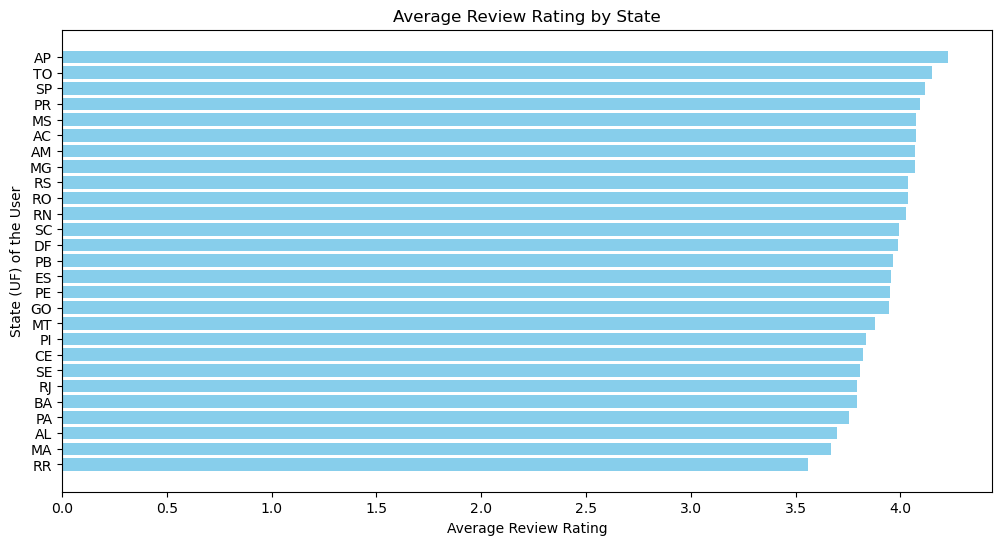

In [38]:
# Plot bar chart

plt.figure(figsize = (12, 6))
plt.barh(avg_score_per_state['customer_state'], avg_score_per_state['Average Review Ratings'], color = 'skyblue')
plt.ylabel('State (UF) of the User')
plt.xlabel('Average Review Rating')
plt.title('Average Review Rating by State')
plt.show()

### Question 4.4 – Customer Satisfaction Level with Gauge Charts

In [39]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116581 entries, 0 to 116580
Data columns (total 64 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       116581 non-null  object         
 1   order_id3                      116581 non-null  object         
 2   customer_id3                   116581 non-null  object         
 3   order_status                   116581 non-null  object         
 4   order_purchase_timestamp       116581 non-null  datetime64[ns] 
 5   order_approved_at              116581 non-null  datetime64[ns] 
 6   order_delivered_carrier_date   116581 non-null  datetime64[ns] 
 7   order_delivered_customer_date  116581 non-null  datetime64[ns] 
 8   order_estimated_delivery_date  116581 non-null  datetime64[ns] 
 9   order_item_id                  116581 non-null  float64        
 10  product_id3                    116581 non-null  object  

In [40]:
# Average review by user state

avg_score_per_user = df2.groupby('customer_id', as_index = False).agg({'review_score': ['mean']})
avg_score_per_user.columns = ['customer_id', 'Average Review Ratings']

In [41]:
avg_score_per_user.head()

,customer_id,Average Review Ratings
0,1,1.0
1,2,3.0
2,3,5.0
3,4,5.0
4,5,5.0


In [42]:
avg_score_per_user.shape

(97255, 2)

It would be unfeasible to present a chart with this volume of data. Let’s simplify the data and observe it from a different perspective.

In [43]:
avg_score_per_user['Average Review Ratings'].value_counts()

Average Review Ratings
5.000000    56211
4.000000    18760
1.000000    10974
3.000000     8091
2.000000     3093
4.500000       54
2.500000       36
3.500000       26
1.500000        8
3.333333        1
4.333333        1
Name: count, dtype: int64

In [44]:
# Function to separate the reviews in 3 tiers

def label_review(row):
    if row['Average Review Ratings'] > 3.0 :
        return 'Satisfied'
    if row['Average Review Ratings'] < 3.0 :
        return 'Dissatisfied'
    if row['Average Review Ratings'] == 3.0 :
        return 'Neutral'

In [45]:
# Apply the function

avg_score_per_user['satprediction'] = avg_score_per_user.apply(lambda row: label_review(row), axis = 1)

In [46]:
# Count per element

count_per_element = avg_score_per_user['satprediction'].value_counts()

In [47]:
count_per_element

satprediction
Satisfied       75053
Dissatisfied    14111
Neutral          8091
Name: count, dtype: int64

In [48]:
# Convert to Series type

serie = pd.Series(count_per_element)

In [49]:
a = serie.loc['Satisfied']

In [50]:
b = serie.loc['Dissatisfied']

In [51]:
c = serie.loc['Neutral']

In [52]:
# Calculate the percentage of satisfied customers relative to the total.

satisfied_percentual = (a / (a + b + c)) * 100

In [53]:
satisfied_percentual

77.17135365790962

In [54]:
# Plot
# Note that we will use 70% as the reference threshold.

fig = go.Figure(go.Indicator(domain = {'x': [0, 1], 'y': [0, 1]},
                             value = satisfied_percentual,
                             mode = "gauge+number+delta",
                             title = {'text': "Customer Satisfaction Level\n"},
                             delta = {'reference': 70},
                             gauge = {'axis': {'range': [None, 100]}, 'steps' : [
                                 {'range': [0, 50], 'color': "lightgray"},
                                 {'range': [50, 80], 'color': "gray"}],
                                      'threshold' : {'line': {'color': "red", 'width': 4}, 
                                                     'thickness': 0.75, 'value': 70}}))

fig.show()

## Section 5 - Marketing Analytics Metrics

### Question 5.1 - Métricas Horizontais

Horizontal metrics are performance indicators that can be applied and compared across different industries, products, or channels. They provide an overall view of performance and are useful for benchmarking and general comparisons.

These metrics are less focused on the specific details of a product, campaign, or industry, and more on broader trends and patterns that can be observed across multiple sectors.

In [55]:
# Total payment value by year

total_rev_year = df2.groupby(['order_purchase_year'], as_index = False).payment_value.sum()

In [56]:
total_rev_year

,order_purchase_year,payment_value
0,2016,75044.76
1,2017,9080448.56
2,2018,11002557.43


In [57]:
# Get the unique order IDs
total_orders = df2.groupby(['order_purchase_year'], as_index = False).order_id.nunique()
total_orders

,order_purchase_year,order_id
0,2016,309
1,2017,43788
2,2018,53158


In [58]:
# Number of unique category

total_category = df2.product_category_name.nunique()
total_category

71

In [59]:
# Number of unique Clients

total_customers = df2.customer_unique_id.nunique()
total_customers

94087

### Question 5.2 – Vertical Metrics

Vertical metrics are performance indicators specific to a particular industry, market niche, or product type. They take into account the unique characteristics and requirements of specific sectors or campaigns.

These metrics focus on the detailed and specialized aspects of an industry or campaign, providing more precise and relevant insights for specific objectives.

In [60]:
# Filtering 2018 data

df2018 = df[df.order_purchase_year == 2018]

In [61]:
# Total Sales by Category

sales_per_category = df2018.groupby(['product_category_name_english'], as_index = False).payment_value.sum()
sales_per_category = sales_per_category.sort_values(by = ['payment_value'], ascending = False)
sales_per_category.columns = ['Product Category', 'Sales Revenue']

In [62]:
# Filtering the Top 20

sales_per_category = sales_per_category[:20]

In [63]:
# Labels and values

labels = sales_per_category['Product Category']
values = sales_per_category['Sales Revenue']

In [64]:
# Horizontal bar chart

fig = go.Figure(data = [go.Bar(x = values, y = labels, orientation = 'h')])

# Add Title and Axis Labels

fig.update_layout(title = 'Total Sales by Category in 2018',
                  xaxis_title = 'Sales Revenue',
                  yaxis_title = 'Product Category',
                  yaxis = {'categoryorder':'total ascending'})  # Orders the bar by revenue

# Show the Chart

fig.show()

### Question 5.3 – Sales Revenue by Category, Year, and Month – Working with Four Dimensions

In this section, we will test some visualizations, demonstrate poor visualization practices, and finally suggest a better approach.

In [65]:
# Sales by Category Over the Years

total_rev = df2.groupby(['order_purchase_year', 
                            'order_purchase_mon', 
                            'product_category_name_english'], as_index = False).payment_value.sum()

In [66]:
# Adjust the column names.

total_rev.columns = ['Sales Year', 'Sales Month', 'Product Category', 'Sales Revenue']

In [67]:
total_rev.head()

,Sales Year,Sales Month,Product Category,Sales Revenue
0,2016,Dec,fashion bags accessories,19.62
1,2016,Oct,air conditioning,4675.43
2,2016,Oct,audio,183.03
3,2016,Oct,auto,2716.70
4,2016,Oct,baby,2344.43


In [68]:
# Plot with 4 dimensions (DO NOT USE SOMETHING LIKE THIS)

fig = px.sunburst(total_rev, 
                  path = ['Sales Year', 'Product Category', 'Sales Month'], 
                  values = 'Sales Revenue',
                  color = 'Sales Revenue', 
                  hover_data = ['Sales Revenue'],
                  color_continuous_scale = 'RdBu',
                  color_continuous_midpoint = np.average(total_rev['Sales Revenue'], 
                                                         weights = total_rev['Sales Revenue']))
fig.show()

In [69]:
# Plot with 3 dimensions (Still not good!)

fig = px.sunburst(total_rev, 
                  path = ['Sales Year', 'Product Category'], 
                  values = 'Sales Revenue',
                  color = 'Sales Revenue', 
                  hover_data = ['Sales Revenue'],
                  color_continuous_scale = 'RdBu',
                  color_continuous_midpoint = np.average(total_rev['Sales Revenue'], 
                                                         weights = total_rev['Sales Revenue']))
fig.show()

In [70]:
# Plotting the bar chart (Still not ideal!)

fig = px.bar(total_rev, 
             x = 'Product Category', 
             y = 'Sales Revenue', 
             color = 'Sales Revenue', 
             facet_col = 'Sales Year',  # Create a separate chart for each year of sales
             hover_data = ['Sales Revenue'],
             color_continuous_scale = 'RdBu',
             color_continuous_midpoint = np.average(total_rev['Sales Revenue'], 
                                                    weights = total_rev['Sales Revenue']))

fig.show()

In [71]:
total_rev.shape

(1252, 4)

For optimal visualization, we need to reduce the dataset, so we will filter to just one year.

In [72]:
# Filtering only 2018

df2_2018 = df2[df2['order_purchase_year'] == 2018]

In [73]:
# Sales throughout 2018

total_rev_2018 = df2_2018.groupby(['order_purchase_year', 
                              'order_purchase_mon', 
                              'product_category_name_english'], as_index = False).payment_value.sum()

In [74]:
# Adjust columns names

total_rev_2018.columns = ['Sales Year', 'Sales Month', 'Product Category', 'Sales Revenue']

In [75]:
total_rev_2018.shape

(518, 4)

In [76]:
# Plot of 2018 data (Starting to improve!)

fig = px.sunburst(total_rev_2018, 
                  path = ['Sales Year', 'Product Category', 'Sales Month'], 
                  values = 'Sales Revenue',
                  color = 'Sales Revenue', 
                  hover_data = ['Sales Revenue'],
                  color_continuous_scale = 'RdBu',
                  color_continuous_midpoint = np.average(total_rev_2018['Sales Revenue'], 
                                                         weights = total_rev_2018['Sales Revenue']))
fig.show()

In [77]:
# Ordering the result by total revenue

total_rev_2018 = total_rev_2018.sort_values(by = 'Sales Revenue', ascending = True)

In [78]:
# Filtering Top 10

total_rev_2018 = total_rev_2018[:10]

In [79]:
# Plot

fig = px.sunburst(total_rev_2018, 
                  path = ['Sales Year', 'Product Category', 'Sales Month'], 
                  values = 'Sales Revenue',
                  color = 'Sales Revenue', 
                  hover_data = ['Sales Revenue'],
                  color_continuous_scale = 'RdBu',
                  color_continuous_midpoint = np.average(total_rev_2018['Sales Revenue'], 
                                                         weights = total_rev_2018['Sales Revenue']))
fig.show()

In [80]:
# Bar Plot

fig = px.bar(total_rev_2018, 
             x = 'Product Category', 
             y = 'Sales Revenue', 
             color = 'Sales Revenue', 
             facet_col = 'Sales Year',  # Create a separate chart for each year of sales
             facet_row = 'Sales Month', # Create a separate subchart for each month of sales
             hover_data = ['Sales Revenue'],
             color_continuous_scale = 'RdBu',
             height = 1000,
             color_continuous_midpoint = np.average(total_rev_2018['Sales Revenue'], 
                                                    weights = total_rev_2018['Sales Revenue']))

fig.show()

### Question 5.4 – Sales Revenue by Hour – Bar Chart vs Pie Chart

In [81]:
# Sales revenue in 2018 grouped by the hour of the day when the sale occurred.

total_rev_hour = df2[df2['order_purchase_year'] == 2018].groupby(['order_purchase_hour'], 
                                                                       as_index = False).payment_value.sum()

In [82]:
 # Adjust columns names 

total_rev_hour.columns = ['Sales Hour', 'Sales Revenue']

In [83]:
total_rev_hour.head()

,Sales Hour,Sales Revenue
0,0,259590.91
1,1,94903.13
2,2,48887.02
3,3,27073.97
4,4,15865.59


In [84]:
total_rev_hour.tail()

,Sales Hour,Sales Revenue
19,19,639093.04
20,20,679084.34
21,21,641839.78
22,22,591816.53
23,23,371116.32


In [85]:
# Sales hour labels

labels = total_rev_hour['Sales Hour']

In [86]:
# Sales revenue Values

values = total_rev_hour['Sales Revenue']

In [87]:
# Bar plot

fig = go.Figure(data = [go.Bar(x = labels, y = values, marker_line_width = 0)]) 

# Add title and Axes labels

fig.update_layout(title = 'Sales Revenue by Hour – Bar Chart”',
                  xaxis_title = 'Day Hour',
                  yaxis_title = 'Sales Revenue')

# Show plot

fig.show()

In [88]:
# Prepare Data

labels = total_rev_hour['Sales Hour']
values = total_rev_hour['Sales Revenue']

In [89]:
# Pie chart

fig = go.Figure(data = [go.Pie(labels = labels, values = values, hole = .2)])

# Add title and Axes labels

fig.update_layout(title = 'Sales Revenue by Hour – Pie Chart”',
                  xaxis_title = 'Day Hour',
                  yaxis_title = 'Sales Revenue')

# Show plot

fig.show()

In [90]:
# Sales by category by hour (alternative to the pie chart).

fig = px.sunburst(total_rev_hour, 
                  path = ['Sales Hour'], 
                  values = 'Sales Revenue',
                  color = 'Sales Revenue', 
                  hover_data = ['Sales Revenue'],
                  color_continuous_scale = 'RdBu',
                  color_continuous_midpoint = np.average(total_rev_hour['Sales Revenue'], 
                                                         weights = total_rev_hour['Sales Revenue']))

# Add title and Axes labels

fig.update_layout(title = 'Sales Revenue by Hour – Sunburst Chart')

# show plot

fig.show()

### Questiom 5.5 - Category Sales by Weekday

In [91]:
# Category Sales by Weekday in 2018

total_rev_hour = df2[df2['order_purchase_year'] == 2018].groupby(['order_purchase_day', 
                                                                        'product_category_name_english'], 
                                                                       as_index = False).payment_value.sum()

In [92]:
total_rev_hour.columns = ['Sales DayofWeek', 'Product Category' , 'Sales Revenue']
total_rev_hour.head()

,Sales DayofWeek,Product Category,Sales Revenue
0,Fri,agro industry and commerce,5839.40
1,Fri,air conditioning,5826.38
2,Fri,art,2398.56
3,Fri,arts and craftmanship,408.95
4,Fri,audio,4834.79


In [93]:
# Plot

# Labels
labels = total_rev_hour['Sales DayofWeek']
values = total_rev_hour['Sales Revenue']

# Chart
fig = go.Figure(data = [go.Bar(x = labels, y = values)])

# Add title and axes labels

fig.update_layout(title = 'Sales Revenue by Category by Dayofweek')
fig.show()

###  Question 5.6 - Total Sales by Category and Weekday – Sunburst Chart

In [94]:
# Order the result by Sales revenue
total_rev_hour = total_rev_hour.sort_values(by = 'Sales Revenue', ascending = True)

In [95]:
total_rev_hour = total_rev_hour[:10]

In [96]:
# Plot
fig = px.sunburst(total_rev_hour, 
                  path = ['Sales DayofWeek', 'Product Category'], 
                  values = 'Sales Revenue',
                  color = 'Sales Revenue', 
                  hover_data = ['Product Category'],
                  color_continuous_scale = 'RdBu',
                  color_continuous_midpoint = np.average(total_rev_hour['Sales Revenue'], 
                                                         weights = total_rev_hour['Sales Revenue']))
fig.show()

In [97]:
# Plot

# Labels
labels = total_rev_hour['Sales DayofWeek']
values = total_rev_hour['Sales Revenue']

# Bar Chart

fig = go.Figure(data = [go.Bar(x = labels, y = values)])

# Add title and axes labels

fig.update_layout(title = 'Sales Revenue by Category by Dayofweek')
fig.show()

### Question 5.7 – Activities by Category with a Funnel Chart

In [98]:
# Orders by category

cat_activity = df2[df2['order_purchase_year'] == 2018].groupby(['product_category_name_english']).order_id.nunique()
cat_activity = pd.DataFrame(cat_activity)
cat_activity.columns = [ 'Activity']
cat_activity = cat_activity.sort_values(by = ['Activity'], ascending = False)
cat_activity.head()

,Activity
product_category_name_english,
health beauty,5402
bed bath table,4909
sports leisure,4058
computers accessories,4053
watches gifts,3493


In [99]:
# Plot

fig = px.funnel_area(names = cat_activity.index, values = cat_activity.Activity)
fig.show()

### In this long project, we analyze sales data from different perspectives. We demonstrated the difference between good and poor visualizations and how they can be improved. Furthermore, we could select some of these metrics and KPIs to develop a BI solution to present to the business area.